In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
OUR_RESULT_CSV = "../../out/table/magic_breakdown.csv"
EDPC_RESULT_CSV = "../../out/table/EDPC_results.csv"

In [3]:
pd.options.display.float_format = "{:.3f}".format
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    }
)

In [4]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [5]:
def load_edpc(csv_name):
    df = pd.read_csv(csv_name)
    df["factory"] = "outer"
    df["layer_count"] = 1
    df["allocator"] = "naive"
    df["msf_coeff"] = 0
    df["msf_prep_time"] = 0
    df["routing_algo"] = "EDPC"
    df["routing_option"] = "Yes_Kink"
    return df


def modify(df):
    instruction_count = {
        c: get_number_of_instructions(c) for c in df["circuit"].unique()
    }
    df["instruction_count"] = df["circuit"].map(instruction_count)
    df["cbpi"] = df["total_code_beat"] / df["instruction_count"]
    df["architecture"] = (
        df["layer_count"].map({1: "2D", 2: "2.5D"}) + " " + df["factory"]
    )
    df["allocator_msf"] = df["allocator"] + " " + df["msf_coeff"].astype(str)

    # As the Single 2D results assumes that paths take 2 code beat,
    # the cost should be doubled.
    # Also, the `yes_kink` cost should be the `no_kink` cost.
    mask = (df["routing_algo"] == "Single") & (df["layer_count"] == 1)
    metrics_cols = ["total_code_beat", "circuit_volume", "cbpi"]
    df.loc[mask, metrics_cols] *= 2

    df_single_2d = df[mask]
    df_single_2d_yes_kink = df_single_2d[
        df_single_2d["routing_option"] == "No_Kink"
    ].copy()
    df_single_2d_yes_kink["routing_option"] = "Yes_Kink"

    df = pd.concat((df, df_single_2d_yes_kink)).reset_index(drop=True)
    return df

In [6]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]

In [7]:
order_info = {
    "architecture": ["2D outer", "2D inner", "2.5D outer", "2.5D inner"],
    "allocator": ["naive", "random", "SA"],
    "routing_algo": ["Single", "Double", "Proj."],
}

In [8]:
df_ours = modify(pd.read_csv(OUR_RESULT_CSV))
df_ours_best_sa = extract_best_sa(df_ours)
df_edpc = modify(load_edpc(EDPC_RESULT_CSV))

## Routing Comparison

### Routing + Mapping でプロット

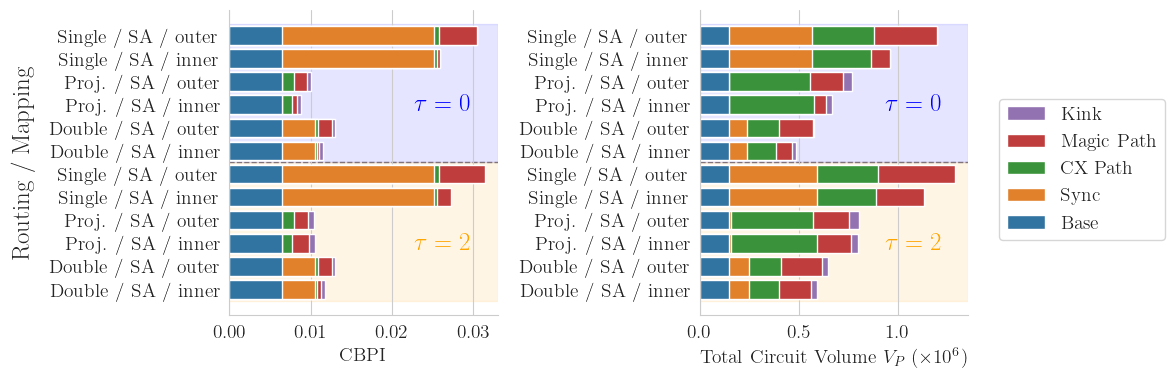

In [9]:
# 2.5D も追加した version

option_styles = {
    "No_MSF": {"label": "Sync", "color": "C1"},
    "No_MP": {"label": "CX Path", "color": "C2"},
    "No_Kink": {"label": "Magic Path", "color": "C3"},
    "Yes_Kink": {"label": "Kink", "color": "C4"},
}

delim = r" / "

layer_count_repr_dict = {1: "2D", 2: "2.5D"}

x_column_name = f"Routing{delim}Mapping{delim}Layout{delim}Prep"

routing_allocator_dimensions = [
    # f"EDPC{delim}naive{delim}outer",
    f"Single{delim}SA{delim}outer{delim}0",
    f"Single{delim}SA{delim}inner{delim}0",
    f"Proj.{delim}SA{delim}outer{delim}0",
    f"Proj.{delim}SA{delim}inner{delim}0",
    f"Double{delim}SA{delim}outer{delim}0",
    f"Double{delim}SA{delim}inner{delim}0",
    f"Single{delim}SA{delim}outer{delim}2",
    f"Single{delim}SA{delim}inner{delim}2",
    f"Proj.{delim}SA{delim}outer{delim}2",
    f"Proj.{delim}SA{delim}inner{delim}2",
    f"Double{delim}SA{delim}outer{delim}2",
    f"Double{delim}SA{delim}inner{delim}2",
]

df_merged = pd.concat((df_ours_best_sa, df_edpc))

df_merged[x_column_name] = (
    df_merged["routing_algo"]
    + delim
    + df_merged["allocator"]
    + delim
    + df_merged["factory"]
    + delim
    + df_merged["msf_prep_time"].astype(str)
)

df_arc = df_merged[
    # (df_merged["factory"] == "outer") &
    (df_merged["allocator"] == "SA")
    # & (df_merged["msf_prep_time"] == 0)
].copy()
df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
    if "SELECT" in str(circuit) and str(circuit).endswith("6"):
        sns.set_style(
            "whitegrid",
            rc={
                "text.usetex": True,
                "font.family": "serif",
                "font.serif": ["Computer Modern Roman"],
                "font.size": 14,
            },
        )
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, metric, xlabel in zip(
            axes,
            ["cbpi", "circuit_volume_scaled"],
            ["CBPI", r"Total Circuit Volume $V_P$ ($\times10^6$)"],
        ):
            stack_height = []
            for routing_option, style in reversed(option_styles.items()):
                sns.barplot(
                    data=df_circuit[df_circuit["routing_option"] == routing_option],
                    x=metric,
                    y=x_column_name,
                    ax=ax,
                    order=routing_allocator_dimensions,
                    **style,
                )
            base = df_circuit[
                (df_circuit["routing_algo"] == "Proj.")
                & (df_circuit["routing_option"] == "No_MSF")
            ][metric].iloc[0]

            df_base = pd.DataFrame(
                {
                    x_column_name: routing_allocator_dimensions,
                    metric: [base] * len(routing_allocator_dimensions),
                }
            )
            sns.barplot(
                data=df_base,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=routing_allocator_dimensions,
                color="C0",
                label="Base",
            )
            # sns.barplot(
            #     data=df_circuit,
            #     x=metric,
            #     y=x_column_name,
            #     ax=ax,
            #     order=[routing_allocator_dimensions[0]],
            #     color="gray",
            # )

            # y軸のラベルを短いものに置き換え（FixedLocatorで警告回避）
            ax.set_yticks(range(len(routing_allocator_dimensions)))
            ax.set_yticklabels(
                list(map(lambda s: s[0 : s.rfind(delim)], routing_allocator_dimensions))
            )
            ax.set_xlabel(xlabel)

            # 背景に2Dと2.5Dの注釈を追加
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            y_line = 5.5
            ax.axhline(y=y_line, color="gray", linestyle="--", linewidth=1, zorder=0)
            ax.axhspan(-0.5, y_line, alpha=0.1, color="blue", zorder=0)
            ax.axhspan(y_line, 11.5, alpha=0.1, color="orange", zorder=0)

            # 2Dのテキスト
            for y, text_content, color in [
                (3, r"$\tau = 0$", "blue"),
                (9, r"$\tau = 2$", "orange"),
            ]:
                ax.text(
                    xlim[1] * 0.9,
                    y,
                    text_content,
                    ha="right",
                    va="center",
                    fontsize=18,
                    weight="bold",
                    color=color,
                )

            sns.despine(ax=ax)
        # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

        axes[0].set_ylabel(f"Routing{delim}Mapping", fontsize=18, labelpad=10)
        axes[1].set_ylabel("")

        axes[0].get_legend().remove()
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].get_legend().remove()
        fig.legend(
            handles,
            labels,
            loc="upper left",
            bbox_to_anchor=(1, 0.75),
        )

        plt.tight_layout()
        plt.savefig(
            "../../fig/magic_breakdown.pdf",
            bbox_inches="tight",
        )
        plt.show()

In [10]:
df_arc[(df_arc["routing_algo"] == "Double") & (df_arc["allocator"] == "SA")]

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,Routing / Mapping / Layout / Prep,circuit_volume_scaled
147,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Double,No_Kink,7536,1024233,12242,0.616,2D inner,SA 0.001,Double / SA / inner / 0,1.024
1169,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.010,2,Double,No_Kink,7537,1019904,12242,0.616,2D inner,SA 0.01,Double / SA / inner / 2,1.020
146,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Double,No_MP,7536,972134,12242,0.616,2D inner,SA 0.001,Double / SA / inner / 0,0.972
1168,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.010,2,Double,No_MP,7536,981530,12242,0.616,2D inner,SA 0.01,Double / SA / inner / 2,0.982
144,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Double,No_MSF,7536,923848,12242,0.616,2D inner,SA 0.001,Double / SA / inner / 0,0.924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,2,Double,No_MSF,721,148600,27720,0.026,2D outer,SA 0.01,Double / SA / outer / 2,0.149
621,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,0,Double,No_Top,721,72100,27720,0.026,2D outer,SA 0.01,Double / SA / outer / 0,0.072
887,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,2,Double,No_Top,1740,225000,27720,0.063,2D outer,SA 0.01,Double / SA / outer / 2,0.225
1520,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.100,0,Double,Yes_Kink,1133,367511,27720,0.041,2D outer,SA 0.1,Double / SA / outer / 0,0.368


## CV-CB Plot

In [11]:
# import matplotlib.patches as patches
from matplotlib.lines import Line2D

factory = "outer"
layer_count = 1

SELECT_REPEAT = 36652
TROTTER_REPEAT = 161636

ENLARGED_MAX_X = 0.5
ENLARGED_MAX_Y = 5

OVERALL_MAX_X = 6.2
OVERALL_MAX_Y = 20

df_all = modify(pd.read_csv(OUR_RESULT_CSV))
df_all = extract_best_sa(df_all)
df_circuit = df_all[
    df_all["circuit"].str.match("result_.*_10_Heisenberg2D_.*", na=False)
]
df_edpc = modify(load_edpc(EDPC_RESULT_CSV))

df_arc = df_circuit[
    (df_circuit["routing_option"] == "Yes_Kink")
    & (df_circuit["allocator"] == "SA")
    # & (
    #     ((df_circuit["factory"] == "outer") & (df_circuit["msf_prep_time"] == 0))
    # | ((df_circuit["factory"] == "inner") & (df_circuit["msf_prep_time"] == 0))
    # | ((df_circuit["factory"] == "outer") & (df_circuit["msf_prep_time"] == 2))
    # | ((df_circuit["factory"] == "inner") & (df_circuit["msf_prep_time"] == 2))
    # )
    & (df_circuit["layer_count"] == layer_count)
].copy()

df_edpc["routing_algo"] = "EDPC"
df_merged = pd.concat((df_edpc, df_arc))
df_merged["total_code_beat_scaled"] = df_merged["total_code_beat"]
df_merged["circuit_volume_scaled"] = df_merged["circuit_volume"]

display(df_merged)

# for routing_algo in ("Double", "Proj"):
# df_ra = df_arc[df_arc["routing_algo"] == routing_algo]
splitted_circuit_series = df_merged["circuit"].str.split("_")
df_merged["circuit_type"] = splitted_circuit_series.map(
    lambda l: "SELECT" if l[1] == "SELECT" else f"Trotter ({l[-1]}.)"
)
df_merged["circuit_suffix"] = splitted_circuit_series.map(lambda l: l[-1])

df_merged["factory_tau"] = (
    df_merged["factory"] + delim + df_merged["msf_prep_time"].astype(str)
)

# display(df_arc)

df_select = df_merged[(df_merged["circuit_type"] == "SELECT")].copy()
df_select["parallel"] = df_select["circuit_suffix"].astype(int)
df_select.sort_values("parallel")
df_select["total_code_beat_scaled"] *= SELECT_REPEAT
df_select["circuit_volume_scaled"] *= SELECT_REPEAT

df_trotter = df_merged[(df_merged["circuit_type"] != "SELECT")].copy()
df_trotter["total_code_beat_scaled"] *= TROTTER_REPEAT
df_trotter["circuit_volume_scaled"] *= TROTTER_REPEAT

# display(df_trotter)

,circuit,total_code_beat,circuit_volume,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,instruction_count,cbpi,architecture,allocator_msf,total_code_beat_scaled,circuit_volume_scaled
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_1,10453,1729600,outer,1,naive,0.000,0,EDPC,Yes_Kink,12314,0.849,2D outer,naive 0,10453,1729600
1,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,3339,652754,outer,1,naive,0.000,0,EDPC,Yes_Kink,27720,0.120,2D outer,naive 0,3339,652754
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,14695,1973490,outer,1,naive,0.000,0,EDPC,Yes_Kink,12242,1.200,2D outer,naive 0,14695,1973490
3,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,2672,544680,outer,1,naive,0.000,0,EDPC,Yes_Kink,27720,0.096,2D outer,naive 0,2672,544680
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_2,8202,1966008,outer,1,naive,0.000,0,EDPC,Yes_Kink,12482,0.657,2D outer,naive 0,8202,1966008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,1749,538067,outer,1,SA,0.001,2,Double,Yes_Kink,27720,0.063,2D outer,SA 0.001,1749,538067
909,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,994,387366,outer,1,SA,1.000,0,Proj.,Yes_Kink,27720,0.036,2D outer,SA 1.0,994,387366
1203,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,1859,769264,outer,1,SA,1.000,2,Proj.,Yes_Kink,27720,0.067,2D outer,SA 1.0,1859,769264
3088,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,1752,487152,outer,1,SA,1.000,0,Single,Yes_Kink,27720,0.063,2D outer,SA 1.0,1752,487152


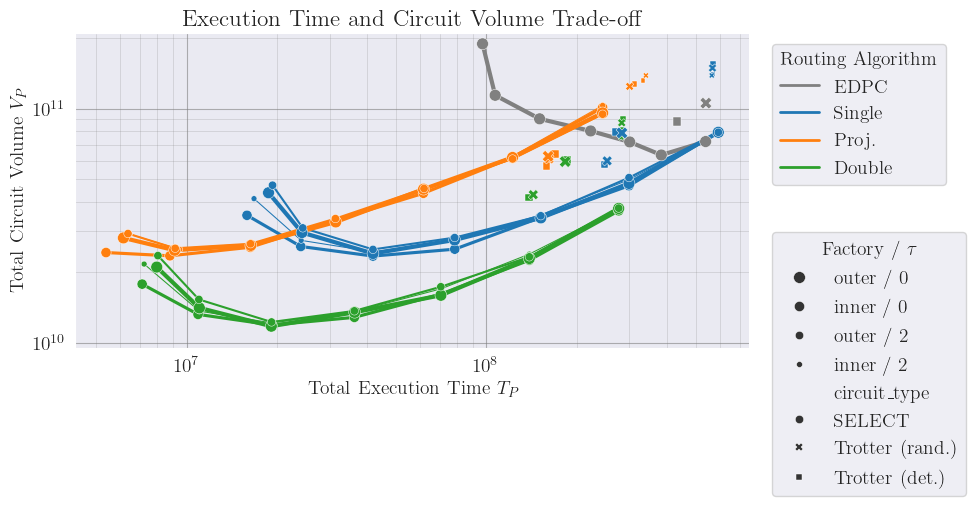

In [12]:
import numpy as np
from matplotlib.ticker import LogLocator

palette = {
    "EDPC": "gray",
    "Single": "C0",
    "Proj.": "C1",
    "Double": "C2",
}

size_order = [
    f"{factory}{delim}{tau}" for tau in (0, 2) for factory in ("outer", "inner")
]

sns.set_style(
    "darkgrid",
    rc={
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    },
)
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    df_select,
    x="total_code_beat_scaled",
    y="circuit_volume_scaled",
    hue="routing_algo",
    hue_order=["EDPC", "Single", "Proj.", "Double"],
    size="factory_tau",
    size_order=size_order,
    legend=False,
    zorder=1,
    ax=ax,
    palette=palette,
)

sns.scatterplot(
    pd.concat((df_select, df_trotter)),
    x="total_code_beat_scaled",
    y="circuit_volume_scaled",
    hue="routing_algo",
    style="circuit_type",
    hue_order=["EDPC", "Single", "Proj.", "Double"],
    size="factory_tau",
    size_order=size_order,
    legend=True,
    markers=True,
    zorder=2,
    ax=ax,
    palette=palette,
)

dim = "2D" if layer_count == 1 else "2.5D"
ax.set_title("Execution Time and Circuit Volume Trade-off")
ax.set_xlabel("Total Execution Time $T_P$")
ax.set_ylabel("Total Circuit Volume $V_P$")
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

ax.grid(True, which="major", alpha=0.6, linestyle="-", linewidth=0.8, color="gray")
ax.grid(True, which="minor", alpha=0.3, linestyle="-", linewidth=0.5, color="gray")

# ここにおかないと、いくつかの設定が上書きされる
sns.despine(ax=ax, left=False, bottom=False)

y_data = pd.concat((df_select, df_trotter))["circuit_volume_scaled"]
y_min = y_data.min()
y_max = y_data.max()
ax.set_ylim(0.95 * 10 ** (np.floor(np.log10(y_min))), y_max * 1.1)

handles, labels = ax.get_legend_handles_labels()

legend1 = ax.legend(
    handles=[
        Line2D([], [], color=palette[name], lw=2, label=name) for name in palette.keys()
    ],
    title="Routing Algorithm",
    loc="upper left",
    alignment="left",
    bbox_to_anchor=(1.02, 1.0),
)

ax.add_artist(legend1)

# https://seaborn.pydata.org/tutorial/properties.html
marker_names = labels[labels.index("circuit_type") + 1 :]
marker_makers = ["o", "X", "s", "P", "D"][: len(marker_names)]

ax.legend(
    handles=[
        Line2D([], [], linestyle="", marker=marker, color="black", label=name)
        for name, marker in zip(marker_names, marker_makers)
    ],
    title="Circuit Type",
    loc="upper left",
    alignment="left",
    handlelength=1.0,
    bbox_to_anchor=(1.02, 0.6),
)

##

# すべてのハンドルとラベルを取得
all_handles, all_labels = ax.get_legend_handles_labels()

# # --- 1. Routing Algorithm (hue) ---
# # paletteのキーに含まれるラベルのみ抽出
# algo_handles = [h for h, l in zip(all_handles, all_labels) if l in palette.keys()]
# legend1 = ax.legend(
#     handles=algo_handles,
#     title="Routing Algorithm",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
# )
# ax.add_artist(legend1)

# # --- 2. Circuit Type (style) ---
# # 既存コードのロジックを流用しつつ、all_handlesから抽出
# try:
#     start_idx = all_labels.index("circuit_type") + 1
#     # 次のセクションの見出し（factory_tau）までの範囲を取得
#     end_idx = all_labels.index("factory_tau")
#     type_handles = all_handles[start_idx:end_idx]
#     type_labels = all_labels[start_idx:end_idx]

#     legend2 = ax.legend(
#         handles=type_handles,
#         labels=type_labels,
#         title="Circuit Type",
#         loc="upper left",
#         bbox_to_anchor=(1.02, 0.7),
#     )
#     ax.add_artist(legend2)
# except ValueError:
#     pass   # ラベルが見つからない場合のフォールバック

# --- 3. Factory tau (size) ---
# "factory_tau" という見出しより後ろにあるものを抽出
try:
    size_start_idx = all_labels.index("factory_tau") + 1
    size_handles = all_handles[size_start_idx:]
    size_labels = all_labels[size_start_idx:]

    ax.legend(
        handles=size_handles,
        labels=size_labels,
        title=r"Factory / $\tau$",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.4),
    )
except ValueError:
    pass

##

plt.tight_layout()
plt.savefig("../../fig/cb_cv_plot_outer_inner_0_2.pdf")
plt.show()